In [31]:

import numpy as np
import matplotlib.pyplot as plt

In [32]:
import cmath

original image


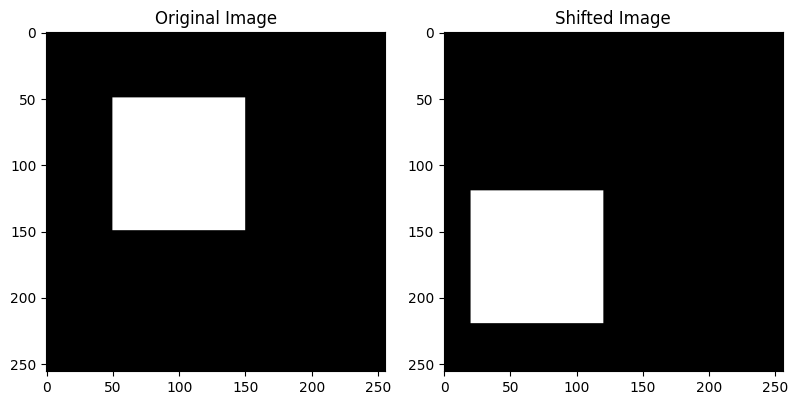

In [33]:
image = plt.imread("image.png")
shifted_image = plt.imread("shifted_image.png")
print("original image")
# print("shifted image")
# print(shifted_image)



plt.figure(figsize=(12, 8))

# Original Image
plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
# plt.axis('off')

# Shifted Image
plt.subplot(2, 3, 2)
plt.imshow(shifted_image, cmap='gray')
plt.title(f"Shifted Image")
# plt.axis('off')


# Reversed Shifted Image
#plt.subplot(2, 3, 3)
#plt.imshow(reversed_shifted_image, cmap='gray')
#plt.title("Reversed Shifted Image")
#plt.axis('off')

plt.tight_layout()
plt.show()



In [34]:
overlap=image * shifted_image

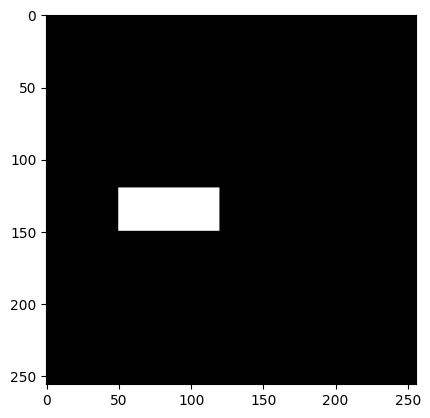

In [35]:
plt.imshow(overlap, cmap="gray")

In [36]:
overlap[140,:]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [37]:
overlap[:,75]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [38]:
def twiddle_factor(N,sign=-1):
    factor = cmath.exp(sign*1j * (2 * np.pi / N)) 
    return complex(round(factor.real, 15), round(factor.imag, 15)) # handling precision


def FFT(time_domain_signal):
    if(len(time_domain_signal)==1):
        return time_domain_signal
    
    time_domain_signal_at_even_indices = time_domain_signal [::2]
    time_domain_signal_at_odd_indices = time_domain_signal [1::2]

    even_FFT=FFT(time_domain_signal_at_even_indices)
    odd_FFT=FFT(time_domain_signal_at_odd_indices)

    N = len(time_domain_signal)

    fft_result = np.zeros(N, dtype=complex)

    for k in range(N//2):
        tdl_fct = twiddle_factor(N) ** k

        fft_result[k] = even_FFT[k] + tdl_fct * odd_FFT[k]
        fft_result[k+N//2] = even_FFT[k] - tdl_fct * odd_FFT[k] 

    return fft_result

def inverse_fft(frequency_domain_signal):
    N = len(frequency_domain_signal)
    if N == 1:
        return frequency_domain_signal
    
    even_part = frequency_domain_signal[::2]
    odd_part = frequency_domain_signal[1::2]
    
    even_IFFT = inverse_fft(even_part)
    odd_IFFT = inverse_fft(odd_part)
    
    ifft_result = np.zeros(N, dtype=complex)
    
    for k in range(N // 2):
        tdl_fct = twiddle_factor(N,sign=1) ** k
        ifft_result[k] = even_IFFT[k] + tdl_fct * odd_IFFT[k]
        ifft_result[k + N // 2] = even_IFFT[k] - tdl_fct * odd_IFFT[k]
    
    return ifft_result

def IFFT(frequency_domain_signal):
    N = len(frequency_domain_signal)
    # Compute the IFFT
    ifft_result = inverse_fft(frequency_domain_signal)
    # Scale the result by 1/N
    return [x / N for x in ifft_result]


def calculate_cross_correlation(signal_a, signal_b):
    FFT_A=FFT(signal_a)
    FFT_B=FFT(signal_b)
    cross_correlation= IFFT(FFT_A* np.conj(FFT_B))

    x_range= np.linspace(0,len(cross_correlation)-1, len(cross_correlation))
    x_range[x_range> len(x_range)/2]-= len(x_range)
    x_range=-x_range

    return cross_correlation, x_range

def sample_lag_detection(cross_correlation, x_range):
    return int(x_range[np.argmax(np.abs(cross_correlation))])

In [39]:
selected_row_from_original_image=image[140,:]

selected_row_from_shifted_image=shifted_image[140,:]

selected_column_from_original_image=image[:,75]

selected_column_from_shifted_image=shifted_image[:,75]

In [40]:
horizontal_shift_cross_correlation, horizontal_x_range = calculate_cross_correlation(selected_row_from_original_image, selected_row_from_shifted_image)

horizontal_shift=sample_lag_detection(horizontal_shift_cross_correlation, horizontal_x_range)

In [41]:
vertical_shift_cross_correlation, vertical_x_range = calculate_cross_correlation(selected_column_from_original_image, selected_column_from_shifted_image)

vertical_shift=sample_lag_detection(vertical_shift_cross_correlation, vertical_x_range)

In [42]:
horizontal_shift, vertical_shift

(-30, 70)

Text(0.5, 1.0, 'Re-aligned image')

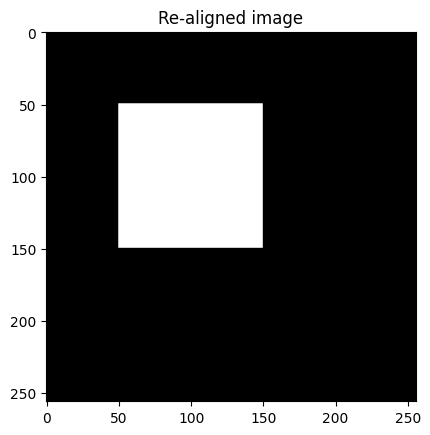

In [43]:
new_image=np.roll(shifted_image,-horizontal_shift, axis=1)

new_image=np.roll(new_image,-vertical_shift, axis=0)

plt.imshow(new_image, cmap="gray")
plt.title("Re-aligned image")
